Place agri_yield_dataset.csv in your notebook working directory and run:

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
# Load the dataset
df = pd.read_csv("agri_yield_dataset.csv")
# 1. Preview top 5 rows
print("--- First 5 Records ---")
display(df.head(5))

--- First 5 Records ---


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,38,37,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [6]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              1500 non-null   str    
 1   Crop               1500 non-null   str    
 2   Soil_Type          1500 non-null   str    
 3   Fertilizer         1500 non-null   str    
 4   N                  1500 non-null   int64  
 5   P                  1500 non-null   int64  
 6   K                  1500 non-null   int64  
 7   Rainfall_mm        1500 non-null   int64  
 8   Temperature_C      1500 non-null   float64
 9   Yield_kg_per_acre  1500 non-null   int64  
 10  Soil_pH            1500 non-null   float64
 11  Year               1500 non-null   int64  
dtypes: float64(2), int64(6), str(4)
memory usage: 140.8 KB


In [7]:
print("--- Summary Statistics ---")
display(df.describe())

--- Summary Statistics ---


,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,74.968000,61.826000,100.374667,174.620667,28.054027,5771.086000,6.781487,2011.996667
std,34.631063,30.092049,51.109814,67.124555,5.493560,12063.581091,0.671793,7.347606
min,10.000000,5.000000,10.000000,50.000000,18.020000,505.000000,5.500000,2000.000000
25%,50.000000,40.000000,62.000000,127.750000,23.932500,1272.750000,6.300000,2006.000000
50%,75.000000,61.000000,101.000000,175.000000,27.955000,2065.500000,6.780000,2012.000000
75%,99.000000,84.000000,135.250000,225.000000,32.240000,2905.250000,7.270000,2019.000000
max,139.000000,119.000000,199.000000,299.000000,37.960000,88401.000000,8.000000,2024.000000


Confirm there are zero missing records and no duplicated entries

In [9]:
# Check for missing values
print("Missing values per column:", df.isnull().sum())

Missing values per column: State                0
Crop                 0
Soil_Type            0
Fertilizer           0
N                    0
P                    0
K                    0
Rainfall_mm          0
Temperature_C        0
Yield_kg_per_acre    0
Soil_pH              0
Year                 0
dtype: int64


In [10]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Duplicate records count: {duplicates_count}")

Duplicate records count: 0


Generate the distribution plot for the target variable and the correlation heatmap for numerical attributes

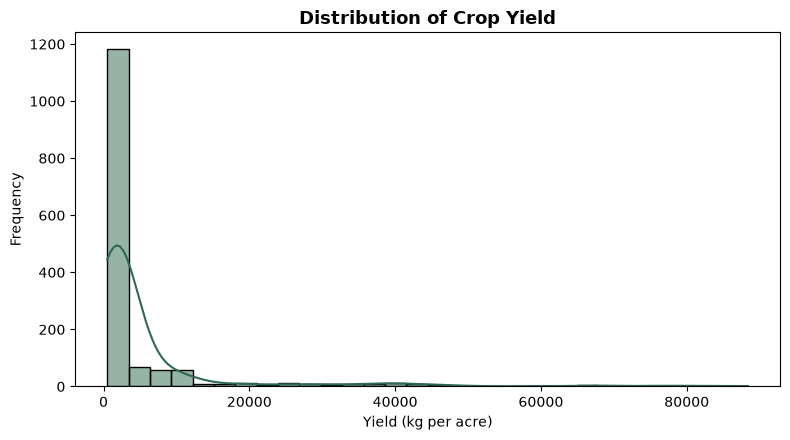

In [11]:
# Graph 1: Distribution of Crop Yield
plt.figure(figsize=(8, 4.5))
sns.histplot(df['Yield_kg_per_acre'], bins=30, kde=True, color='#2d6a4f')
plt.title("Distribution of Crop Yield", fontsize=13, weight='bold')
plt.xlabel("Yield (kg per acre)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

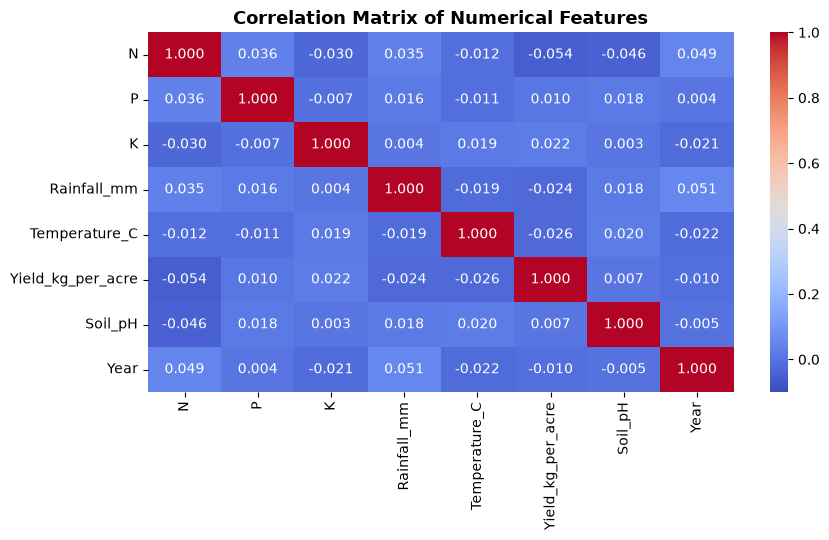

In [12]:
# Graph 2: Numerical Correlation Heatmap
plt.figure(figsize=(9, 5.5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".3f", cmap='coolwarm', vmin=-0.1, vmax=1.0)
plt.title("Correlation Matrix of Numerical Features", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Separate target y from features X, apply one-hot encoding to convert text categories, and scale numerical variables using 
StandardScaler

In [13]:
# Separate features and target
X = df.drop("Yield_kg_per_acre", axis=1)
y = df["Yield_kg_per_acre"]

In [14]:
# One-Hot Encoding on categorical features (drops first level to avoid collinearity)
X_encoded = pd.get_dummies(X, drop_first=True)
print("Shape after One-Hot Encoding:", X_encoded.shape)


Shape after One-Hot Encoding: (1500, 30)


In [15]:
# Standardize numerical features
scaler = StandardScaler()
numerical_cols = ['N', 'P', 'K', 'Rainfall_mm', 'Temperature_C', 'Soil_pH', 'Year']
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])
print("Final dataset shape ready for ML training:", X_encoded.shape)
display(X_encoded.head())

Final dataset shape ready for ML training: (1500, 30)


,N,P,K,Rainfall_mm,Temperature_C,Soil_pH,Year,State_Gujarat,State_Haryana,State_Karnataka,...,Crop_Sugarcane,Crop_Wheat,Soil_Type_Black Soil,Soil_Type_Clay,Soil_Type_Loamy,Soil_Type_Red Soil,Soil_Type_Sandy,Fertilizer_DAP,Fertilizer_Organic,Fertilizer_Urea
0,0.607519,-0.692307,-0.966373,-0.769285,0.547364,0.057348,-1.224843,False,False,True,...,False,False,False,False,True,False,False,True,False,False
1,-1.327806,-0.858520,0.227534,1.078644,1.077252,-0.553163,-1.360988,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,-1.067837,-0.825277,1.499729,-0.486134,-0.699967,0.414721,0.408886,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,-0.490128,0.504421,0.560262,0.780591,0.509125,-1.267907,1.361895,True,False,False,...,False,True,False,False,False,True,False,False,False,False
4,0.954144,-0.027458,-0.731506,1.317086,1.776485,-0.806301,0.681175,False,False,False,...,False,False,False,True,False,False,False,False,True,False


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [17]:
# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [18]:
# 2. Train the Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
# 3. Model evaluation
y_pred = model.predict(X_test)
print(f"Test RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"Test MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test R²   : {r2_score(y_test, y_pred):.4f}")

Test RMSE : 13127.18
Test MAE  : 7501.68
Test R²   : -0.1749


In [22]:
# 4. Predict on a new sample input
sample_raw = pd.DataFrame([{
    'State': 'Punjab',
    'Crop': 'Wheat',
    'Soil_Type': 'Red Soil',
    'Fertilizer': 'Compost',
    'N': 58,
    'P': 77,
    'K': 129,
    'Rainfall_mm': 227,
    'Temperature_C': 30.85,
    'Soil_pH': 5.93,
    'Year': 2022
}])

In [23]:

# Align dummy variables and scale numerical columns
sample_encoded = pd.get_dummies(sample_raw).reindex(columns=X_encoded.columns, fill_value=0)
sample_encoded[numerical_cols] = scaler.transform(sample_encoded[numerical_cols])

In [24]:
# Run inference
predicted_yield = model.predict(sample_encoded)[0]
print(f"\n--- Prediction Result ---")
print(f"Predicted Crop Yield: {predicted_yield:.2f} kg/acre")


--- Prediction Result ---
Predicted Crop Yield: 2130.58 kg/acre
